## ==========================================
## Project: Fitness Retention & Churn Engine
## Author: Kaushik Raj | barnwalkaushik@gmail.com
## ==========================================

### Phase 1: Setup and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('../data/gym_churn_us.csv')

### Phase 2: Initial Inspection

In [2]:
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Check for missing values (Nulls) and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
print(df.isnull().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [5]:
# Look at the basic math (averages, min, max) for anomalies
display(df.describe())

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### Phase 3: Exploratory Data Analysis (EDA) & Correlations

In [6]:
# percentage of churned vs non-churned customers
display(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    73.475
1    26.525
Name: proportion, dtype: float64

In [7]:
# Corelation analysis to see which features are most correlated with churn
raw_correlations = df.corr()['Churn'].sort_values()
print(raw_correlations)

Lifetime                            -0.438220
Avg_class_frequency_current_month   -0.412348
Age                                 -0.404735
Contract_period                     -0.389984
Month_to_end_contract               -0.381393
Avg_class_frequency_total           -0.249715
Avg_additional_charges_total        -0.198697
Group_visits                        -0.175325
Promo_friends                       -0.162233
Partner                             -0.157986
Near_Location                       -0.128098
Phone                               -0.001177
gender                               0.000708
Churn                                1.000000
Name: Churn, dtype: float64


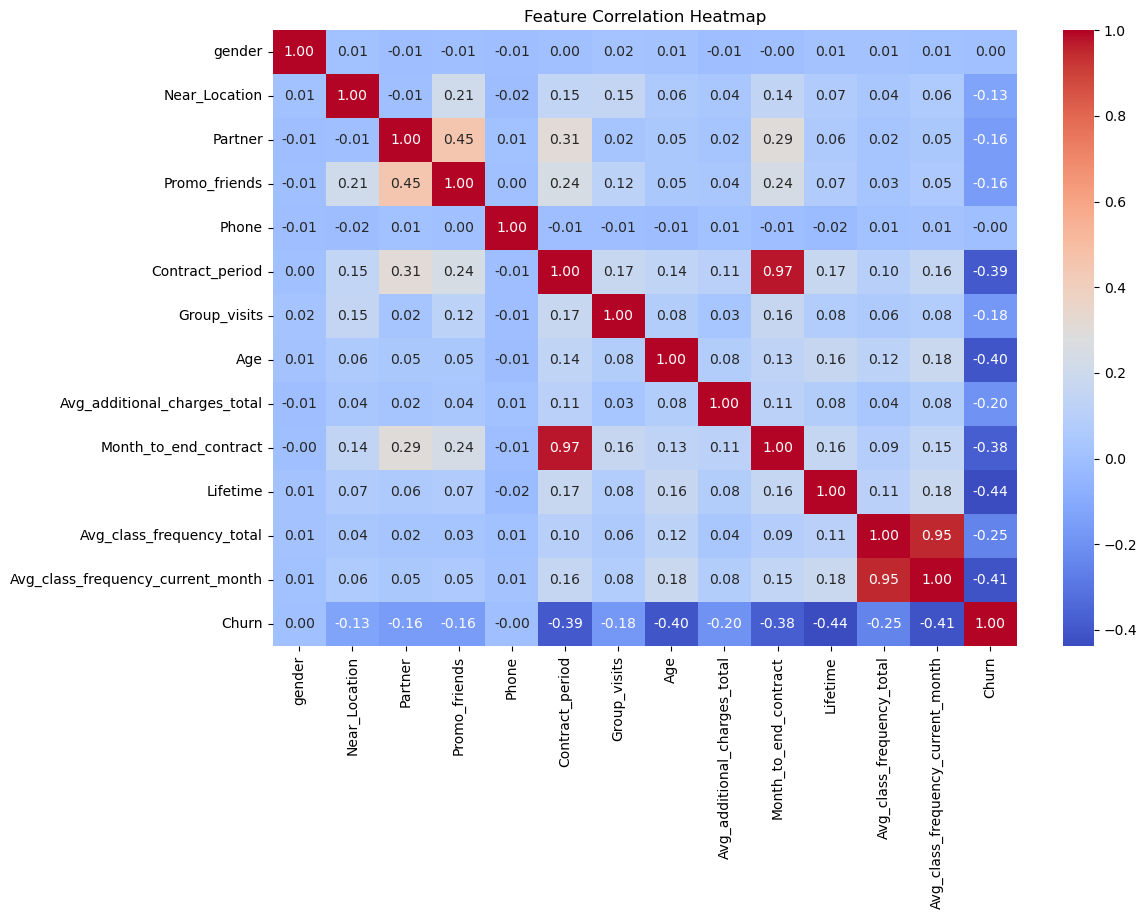

In [8]:
# Visualizing the correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### Phase 4: Data Cleaning & Feature Engineering

In [9]:
# gender and Phone don't predict behavior so dropping these columns from the dataset
df = df.drop(['gender', 'Phone'], axis=1)

In [10]:
# Feature Engineering
# Calculate the drop-off ratio: Current month visits vs Total historical visits
df['freq_ratio'] = df['Avg_class_frequency_current_month'] / (df['Avg_class_frequency_total'] + 0.001)

# Subtracting total average from current month to find momentum shift
df['freq_drop_off'] = df['Avg_class_frequency_current_month'] - df['Avg_class_frequency_total']

# Calculate financial commitment: Total money spent per month of their lifetime
df['charges_per_month'] = df['Avg_additional_charges_total'] / (df['Lifetime'] + 1)

new_correlations = df.corr()['Churn'].sort_values()
# Validating the new features are more correlated with churn than the original features
print(new_correlations[['freq_ratio', 'charges_per_month']])
print(new_correlations[['freq_drop_off', 'charges_per_month']])


freq_ratio          -0.012392
charges_per_month    0.276504
Name: Churn, dtype: float64
freq_drop_off       -0.595550
charges_per_month    0.276504
Name: Churn, dtype: float64


- Division (freq_ratio): The correlation with Churn was -0.012. This is essentially 0. The model saw it as useless random noise.

- Subtraction (freq_drop_off): The correlation with Churn was -0.59. This is a massive, highly predictive signal.

- So, i'm taking freq_drop_off column and dropping freq_ratio

In [11]:
df = df.drop(['freq_ratio'], axis=1)

### Phase 5: Train/Test Split

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)   # 'stratify=y' ensures the 80/20 split maintains the same ratio of churned vs kept users
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (3200, 13)
Testing Data Shape: (800, 13)


### Phase 6: Model Training & Hyperparameter Tuning

In [27]:
# Initializing and training the Random Forest
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

# Making predictions on the hidden 20% test data
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy is: {accuracy * 100:.2f}%")

Model Accuracy is: 96.62%


### Phase 7: Professional Evaluation

In [28]:
# The Classification Report (Precision & Recall)
# Precision: When it predicts Churn, how often is it right?
# Recall: Out of all actual Churners, how many did it find?
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       588
           1       0.96      0.91      0.93       212

    accuracy                           0.97       800
   macro avg       0.96      0.95      0.96       800
weighted avg       0.97      0.97      0.97       800



[[580   8]
 [ 19 193]]


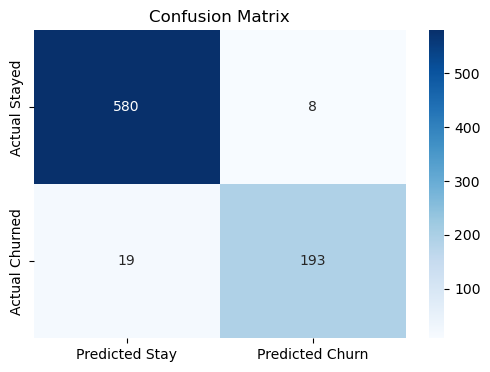

In [29]:
# The Confusion Matrix Visualization
# Shows exactly where the model got confused (True Positives vs False Negatives)
cm = confusion_matrix(y_test, predictions)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Stay', 'Predicted Churn'], yticklabels=['Actual Stayed', 'Actual Churned'])
plt.title('Confusion Matrix')
plt.show()

### Phase 8: Serialization

In [30]:
joblib.dump(model, '../models/churn_production_model.pkl')

['../models/churn_production_model.pkl']